In [343]:
import sys

sys.dont_write_bytecode = True

In [344]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import shuffle

In [345]:
np.random.seed(0)

In [346]:
N = np.int64(1e5)

print(f'Número de Observações: {N}')

Número de Observações: 100000


In [347]:
D = 2

print(f'Dimensão das Observações: {D}')

Dimensão das Observações: 2


In [348]:
M = 5

print(f'Número de Categorias Latentes: {M}')

Número de Categorias Latentes: 5


In [349]:
PI = np.repeat(a = 1/M, repeats = M)

print('Parâmetros das Categorias Latentes:\n')

print(PI)

Parâmetros das Categorias Latentes:

[0.2 0.2 0.2 0.2 0.2]


In [350]:
ALPHA = np.random.multinomial(n = 1, pvals = PI, size  = N)

ALPHA = ALPHA.sum(axis = 0)

print('Número das Observações por Categoria Latente:\n')

print(ALPHA)

Número das Observações por Categoria Latente:

[19837 20253 20054 19942 19914]


In [351]:
MU = [

    [-5, -5, 0, 5, 5],

    [-5, 5, 0, -5, 5]

]

MU = np.array(MU).T

print('Médias por Categoria Latente:\n')

print(MU)

Médias por Categoria Latente:

[[-5 -5]
 [-5  5]
 [ 0  0]
 [ 5 -5]
 [ 5  5]]


In [352]:
SIGMA = [

    [

        [1, -0.7],
        [-0.7, 1]

    ], [

        [1, 0.7],
        [0.7, 1]

    ], [

        [1, 0],
        [0, 1]

    ], [

        [1, 0.7],
        [0.7, 1]

    ], [

        [1, -0.7],
        [-0.7, 1]

    ]

]

SIGMA = np.array(SIGMA)

print('Covariâncias por Categoria Latente:\n')

print(SIGMA)

Covariâncias por Categoria Latente:

[[[ 1.  -0.7]
  [-0.7  1. ]]

 [[ 1.   0.7]
  [ 0.7  1. ]]

 [[ 1.   0. ]
  [ 0.   1. ]]

 [[ 1.   0.7]
  [ 0.7  1. ]]

 [[ 1.  -0.7]
  [-0.7  1. ]]]


In [353]:
X, Z = [], []

for m in range(M):

    X.append(

        np.random.multivariate_normal(

            mean = MU[m], cov = SIGMA[m],

            size = ALPHA[m]

        )

    )

    Z.append(

        np.repeat(

            a = m + 1,
            
            repeats = ALPHA[m]

        )

    )

X = np.vstack(X)

Z = np.hstack(Z)

X, Z = shuffle(X, Z)

In [354]:
DATA = pd.DataFrame(data = X, columns = ['Height', 'Weight'])

DATA['Z'] = Z

DATA.head()

,Height,Weight,Z
0,4.915825,4.618818,5
1,6.727454,-3.522946,4
2,-5.034888,4.225588,2
3,-4.062207,7.269142,2
4,6.729540,-4.424611,4


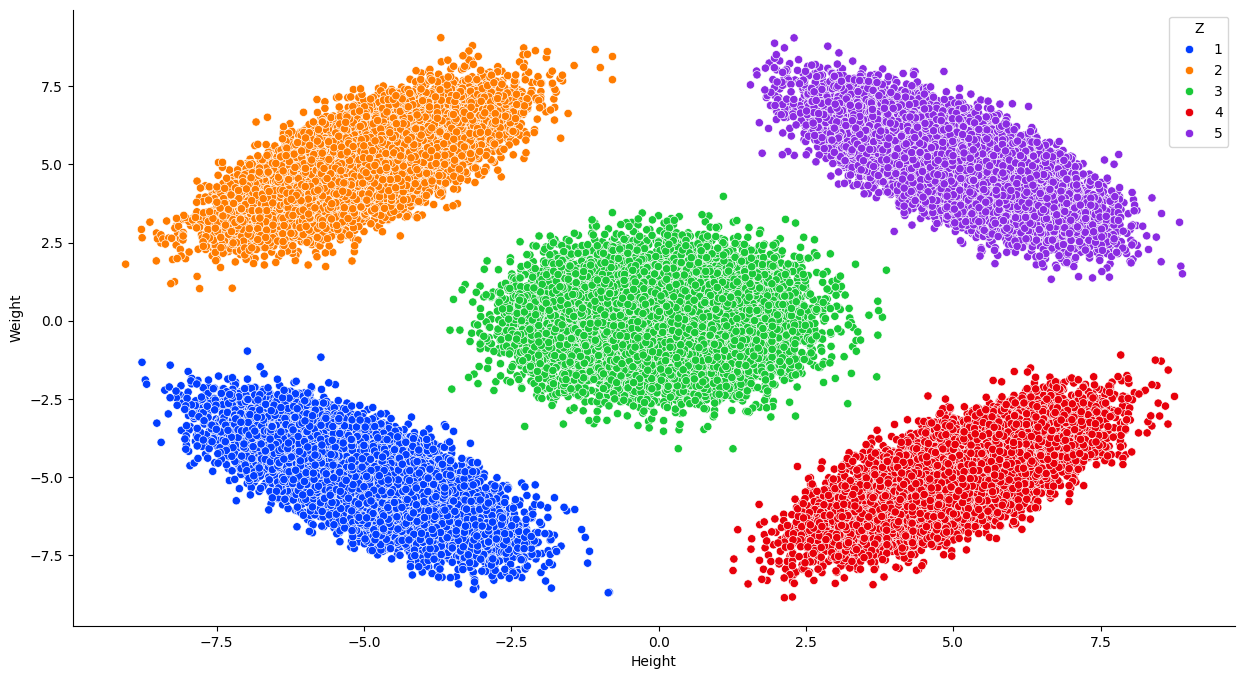

In [355]:
plt.figure(figsize = (15, 8))

Graph = sns.scatterplot(

    data = DATA, x = 'Height', y = 'Weight', 
    
    hue = 'Z', palette = 'bright',

)

Graph.spines['top'].set_visible(False)

Graph.spines['right'].set_visible(False)

plt.show()